In [862]:
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [863]:
# csv url
csv_url = 'https://raw.githubusercontent.com/qeoiruklavmle-ux/Midterm_EDA_Data_Bootcamp/refs/heads/main/Productivity%20Growth%20USA%20All%20Measures.csv'
# load in csv into data frame
productivity = pd.read_csv(csv_url)

In [864]:
# look at the data
productivity.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,BASE_PER,Base period,DECIMALS,Decimals
0,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPEMP,GDP per person employed,...,101.645989,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two
1,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPEMP,GDP per person employed,...,102.775353,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two
2,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPHRS,GDP per hour worked,...,82.105378,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two
3,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,LCEMP,Labour compensation per employee,...,7.453286,NaN,A,Normal value,0,Units,NaN,NaN,2,Two
4,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,LCEMP,Labour compensation per employee,...,6.990554,NaN,A,Normal value,0,Units,NaN,NaN,2,Two


In [865]:
productivity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3428 entries, 0 to 3427
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   STRUCTURE                 3428 non-null   object 
 1   STRUCTURE_ID              3428 non-null   object 
 2   STRUCTURE_NAME            3428 non-null   object 
 3   ACTION                    3428 non-null   object 
 4   REF_AREA                  3428 non-null   object 
 5   Reference area            3428 non-null   object 
 6   FREQ                      3428 non-null   object 
 7   Frequency of observation  3428 non-null   object 
 8   MEASURE                   3428 non-null   object 
 9   Measure                   3428 non-null   object 
 10  ACTIVITY                  3428 non-null   object 
 11  Economic activity         3428 non-null   object 
 12  UNIT_MEASURE              3428 non-null   object 
 13  Unit of measure           3428 non-null   object 
 14  PRICE_BA

In [866]:
# set and sort index as time (year)
productivity.set_index(productivity['TIME_PERIOD'], inplace=True)
productivity.sort_index(inplace = True)

In [867]:
productivity.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,BASE_PER,Base period,DECIMALS,Decimals
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,LCEMP,Labour compensation per employee,...,11.990808,NaN,A,Normal value,0,Units,2015.0,NaN,2,Two
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,ULCE,Unit labour costs (employment based),...,23.264552,NaN,A,Normal value,0,Units,2015.0,NaN,2,Two
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,ULCE,Unit labour costs (employment based),...,23.264552,NaN,A,Normal value,0,Units,2015.0,NaN,2,Two
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,LCHRS,Labour compensation per hour worked,...,11.201002,NaN,A,Normal value,0,Units,2015.0,NaN,2,Two
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,EMP,Employment,...,55.243436,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two


In [868]:
# see what indicators are measured in the data
productivity.groupby('MEASURE')['Measure'].value_counts()

,,count
MEASURE,Measure,
COM,Capital services of telecomunication equipment,76
COM_PCCONK,Contribution of telecomunication equipment to total capital growth,38
CONST,Capital services of non-residential construction,76
CONST_PCCONK,Contribution of non-residential construction to total capital growth,38
EMP,Employment,107
GDP,Gross domestic product,54
GDPEMP,GDP per person employed,107
GDPHRS,GDP per hour worked,57
GDPKSER,Capital productivity,76


In [869]:
# Look at one indicator
productivity[productivity['Measure'] == 'GDP per person employed'].head(3)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,BASE_PER,Base period,DECIMALS,Decimals
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1970,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPEMP,GDP per person employed,...,47.482571,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two
1971,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPEMP,GDP per person employed,...,48.857928,NaN,A,Normal value,0,Units,2020.0,NaN,2,Two
1971,DATAFLOW,OECD.SDD.TPS:DSD_PDB@DF_PDB_GR(1.0),Productivity growth rates,I,USA,United States,A,Annual,GDPEMP,GDP per person employed,...,2.896551,NaN,A,Normal value,0,Units,NaN,NaN,2,Two


There are multiple results for a single indicator in a single year because there are two units of measure: index (IX) and growth rate (PA).

We'll be focusing on the growth rate.

In [870]:
# create a copy of dataframe with only growth rates
prod_growth = productivity[productivity['UNIT_MEASURE'] == 'PA'].copy()

Therer are two measures of productivity growth in this dataset:
*   GDP per person employed (GDPEMP)
*   GDP per hour worked (GDPHRS)



First, we will observe the productivity growth rate measured in GDP per person employed over time.

In [871]:
# create a growth rate dataframe with only GDPEMP (GDP per person employed)
prod_growth_gdpemp = prod_growth[prod_growth['MEASURE'] == 'GDPEMP'].copy()

Text(0, 0.5, 'Growth Rate (%)')

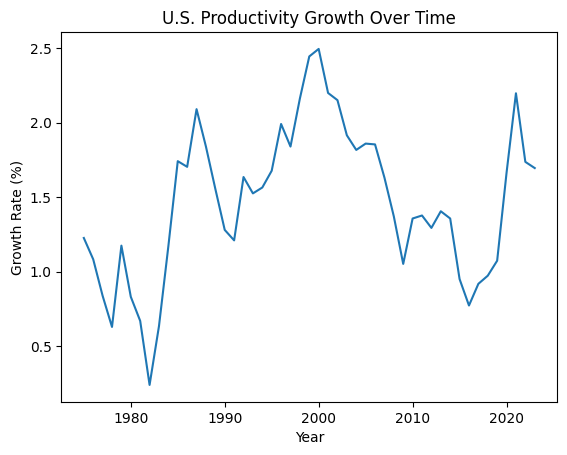

In [872]:
# plot with a rolling mean
prod_growth_gdpemp['roll'] = prod_growth_gdpemp['OBS_VALUE'].rolling(5).mean()
sns.lineplot(data=prod_growth_gdpemp, x=prod_growth_gdpemp.index, y=prod_growth_gdpemp['roll'])
plt.title('U.S. Productivity Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

This graph suggests:
*   Productivity growth is volatile
*   Clear peak around late 1990s to early 2000s.
*   Since the early 2000s, growth appears lower around 1%



Text(0, 0.5, 'Frequency (%)')

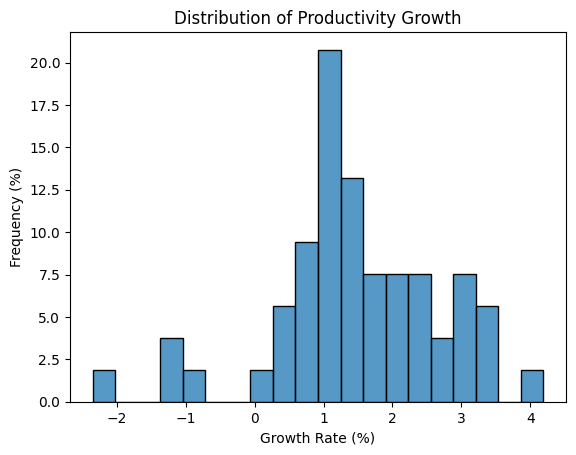

In [873]:
# plot distribution of productivity growth
sns.histplot(data = prod_growth_gdpemp, x=prod_growth_gdpemp['OBS_VALUE'], bins=20, stat='percent')
plt.title('Distribution of Productivity Growth')
plt.xlabel('Growth Rate (%)')
plt.ylabel('Frequency (%)')

This histogram gives insight into how productivity behaves overall, not just over time:

*   Most productivity growth rate is positive
*   Average growth is modest with 20% of observations at around 1%
*   Slightly right skewed as the economy experiences strong productivity surges at times





Now, we compare with GDP per hour worked.

GDP per person employed measures output per worker, but does not account for hours worked. If people work more hours, productivity may look higher even if efficiency hasn’t improved.

In [874]:
# create a copy of dataframe for GDP per hour worked (GDPHRS)
prod_growth_gdphrs = prod_growth[prod_growth['MEASURE'] == 'GDPHRS'].copy()

Text(0, 0.5, 'Growth Rate (%)')

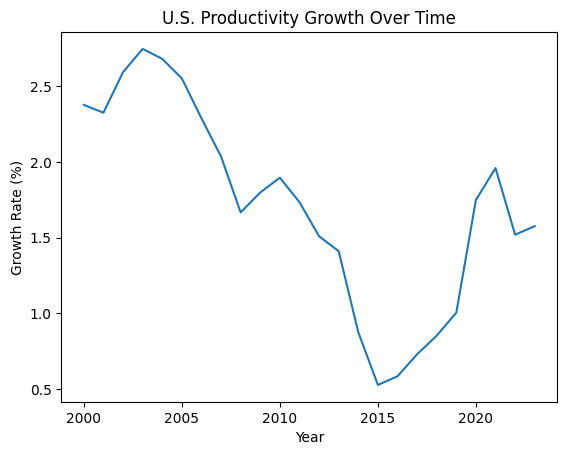

In [875]:
# graph the rolling mean of GDPHRS
prod_growth_gdphrs['roll'] = prod_growth_gdphrs['OBS_VALUE'].rolling(5).mean()
sns.lineplot(data=prod_growth_gdphrs, x=prod_growth_gdphrs.index, y=prod_growth_gdphrs['roll'])
plt.title('U.S. Productivity Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

The graph shows U.S. labor productivity growth measured by GDP per hour worked from 2000 to 2023:
* Productivity growth steadily declines after early 2000s
    * Significant slowdown in productivity growth


Text(0, 0.5, 'Growth Rate (%)')

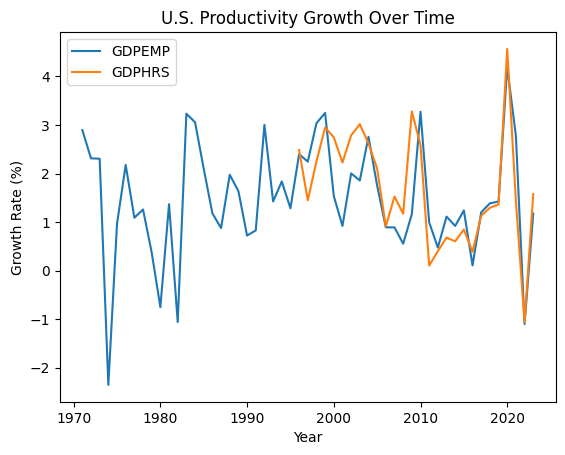

In [876]:
# compare GDPEMP vs. GPHR (without rolling)
prod_growth_gdpemp['OBS_VALUE'].plot(label='GDPEMP')
prod_growth_gdphrs['OBS_VALUE'].plot(label='GDPHRS')
plt.legend()
plt.title('U.S. Productivity Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

This graph shows that:

*   Both are consistent measures of productivity
*   GDP per hour worked is slightly smoother

Text(0, 0.5, 'GDP per Hour Worked Growth (%)')

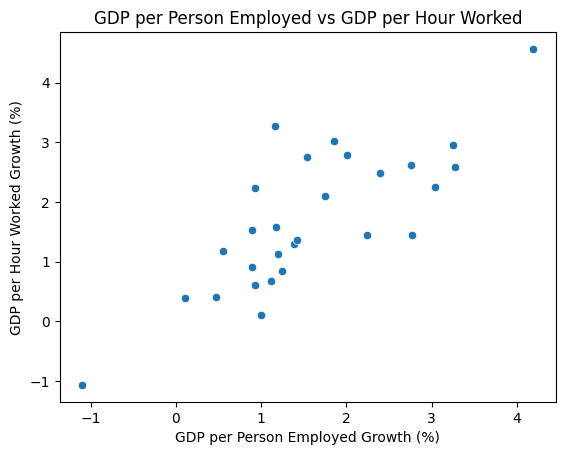

In [877]:
sns.scatterplot(data = prod_growth,
                x=prod_growth[prod_growth['MEASURE']=='GDPEMP']['OBS_VALUE'],
                y=prod_growth[prod_growth['MEASURE']=='GDPHRS']['OBS_VALUE']
                )
plt.title('GDP per Person Employed vs GDP per Hour Worked')
plt.xlabel('GDP per Person Employed Growth (%)')
plt.ylabel('GDP per Hour Worked Growth (%)')

The above graph depicts:

*	A strong positive relationship
    * The two measures of productivity are highly correlated
*	The slowdown is not just due to changes in hours worked
    * Therefore, the slowdown likely reflects real efficiency changes


Text(0, 0.5, 'Frequency (%)')

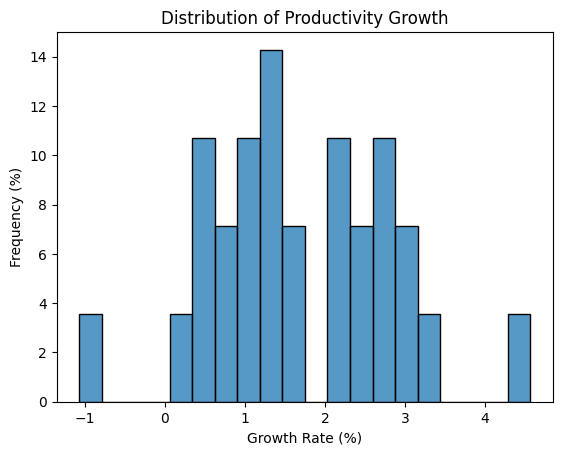

In [878]:
# plot distribution of productivity growth
sns.histplot(data = prod_growth_gdphrs, x=prod_growth_gdphrs['OBS_VALUE'], bins=20, stat='percent')
plt.title('Distribution of Productivity Growth')
plt.xlabel('Growth Rate (%)')
plt.ylabel('Frequency (%)')

The histogram by GDP per hour worked is more centered and concentrated in the lower growth rate range compared to that of GDPEMP.


In [879]:
# split the data into two periods (pre and post 2000)
pre2000 = prod_growth_gdpemp[prod_growth_gdpemp.index < 2000].copy()
post2000 = prod_growth_gdpemp[prod_growth_gdpemp.index >= 2000].copy()

In [880]:
# dictionary to store pre and post percentiles
pct_data = {
    'Percentile': [],
    'Pre': [],
    'Post': []
}

In [881]:
# compare percentiles of two periods
for q in [0.25, 0.5, 0.75]:
  # add percentiles to dictionary
  pct_data['Percentile'].append(int(q*100))
  pct_data['Pre'].append(pre2000['OBS_VALUE'].quantile(q))
  pct_data['Post'].append(post2000['OBS_VALUE'].quantile(q))

  # print results
  print(f'Pre {int(q*100)}th percentile:, {pre2000['OBS_VALUE'].quantile(q): .3f}')
  print(f'Post {int(q*100)}th percentile:, {post2000['OBS_VALUE'].quantile(q): .3f}')
  print(f'Difference: {(post2000['OBS_VALUE'].quantile(q) - pre2000['OBS_VALUE'].quantile(q)): .3f} \n')

Pre 25th percentile:,  0.963
Post 25th percentile:,  0.915
Difference: -0.049 

Pre 50th percentile:,  1.639
Post 50th percentile:,  1.191
Difference: -0.449 

Pre 75th percentile:,  2.314
Post 75th percentile:,  1.778
Difference: -0.537 



Text(0, 0.5, 'Growth Rate (%)')

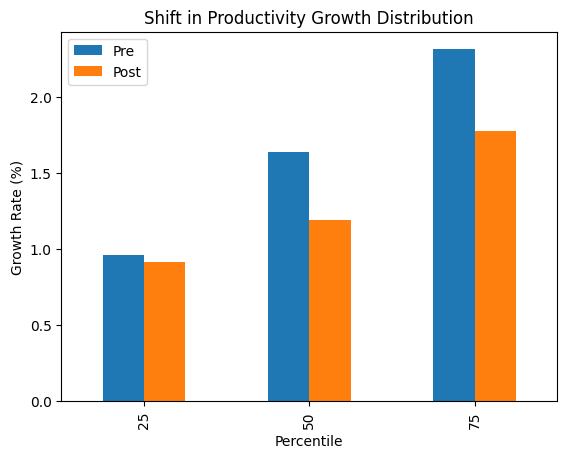

In [882]:
# turn percentiles data into a dataframe and plot a bar graph
pct_data = pd.DataFrame(pct_data)
pct_data.set_index('Percentile').plot(kind='bar')
plt.title("Shift in Productivity Growth Distribution")
plt.ylabel("Growth Rate (%)")

The entire distribution of productivity growth has shifted, indicating a structural change in productivity growth.

Next, we look at correlations between productivity growth rates and other factors, like capital deepening.
* KSERHRS - Capital deepening
* GDPKSER - Capital productivity
* MFPH - Multifactor productivity


In [883]:
# to create a heatmap

# new dataframe with only the factors to examine
selected = prod_growth[
    (prod_growth['MEASURE'] == 'GDP') |
    (prod_growth['MEASURE'] == 'GDPHRS') |
    (prod_growth['MEASURE'] == 'GDPKSER')|
    (prod_growth['MEASURE'] == 'KSERHRS')|
    (prod_growth['MEASURE'] == 'MFPH')
].copy()

In [884]:
# new dataframe with only numeric values (OBS_VALUE)
pivot_growth = selected.pivot(index='TIME_PERIOD', columns='MEASURE', values='OBS_VALUE')
pivot_growth.tail()

MEASURE,GDP,GDPHRS,GDPKSER,KSERHRS,MFPH
TIME_PERIOD,,,,,
2020,-2.163029,4.567876,-4.791811,9.252246,2.036865
2021,6.055053,1.441185,2.573492,-1.210320,1.671172
2022,2.512375,-1.067860,-1.430961,-0.187593,-1.572088
2023,2.887556,1.577162,NaN,NaN,NaN
2024,2.880337,NaN,NaN,NaN,NaN


Text(50.72222222222221, 0.5, 'Indicators')

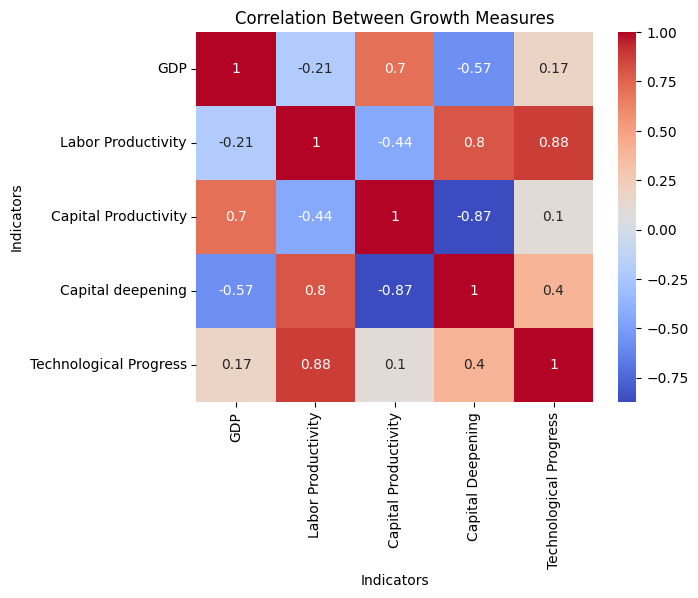

In [885]:
# heatmap for correlations between selected indicators
sns.heatmap(pivot_growth.corr(), annot=True, cmap='coolwarm',
            xticklabels = [
                'GDP',
                'Labor Productivity',
                'Capital Productivity',
                'Capital Deepening',
                'Technological Progress'
            ],
            yticklabels = [
                'GDP',
                'Labor Productivity',
                'Capital Productivity',
                'Capital deepening',
                'Technological Progress'
            ]
            )
plt.title('Correlation Between Growth Measures')
plt.xlabel('Indicators')
plt.ylabel('Indicators')

There is a high correlation between productivity growth rate (GDPHRS) and capital deepening (KSERHRS) and multifactor productivity (MFPH).

Focusing on the high correlation between productivity growth rate and capital deepening rate.

Does capital deepening explain productivity growth trends?

Text(0, 0.5, 'Capital Deepening (%)')

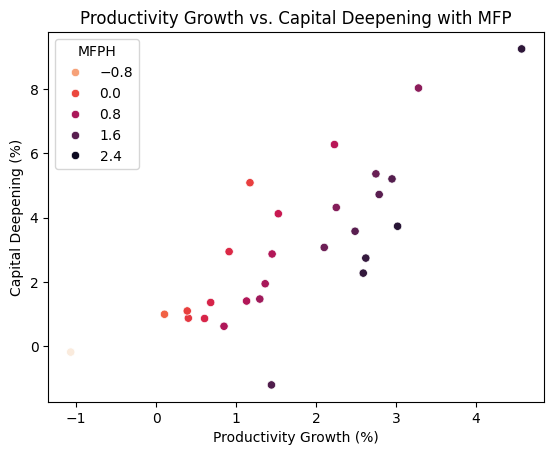

In [886]:
# plot capital deepening vs. productivity growth rate vs. technological progress
sns.scatterplot(data=pivot_growth,
                x=pivot_growth['GDPHRS'],
                y=pivot_growth['KSERHRS'],
                hue=pivot_growth['MFPH'],
                palette='rocket_r'
                )
plt.title('Productivity Growth vs. Capital Deepening with MFP')
plt.xlabel('Productivity Growth (%)')
plt.ylabel('Capital Deepening (%)')

Has capital deepening slowed over time?

Did the slowdown in productivity growth coincide with slower growth in capital per hour worked?

Text(0, 0.5, 'Growth Rate (%)')

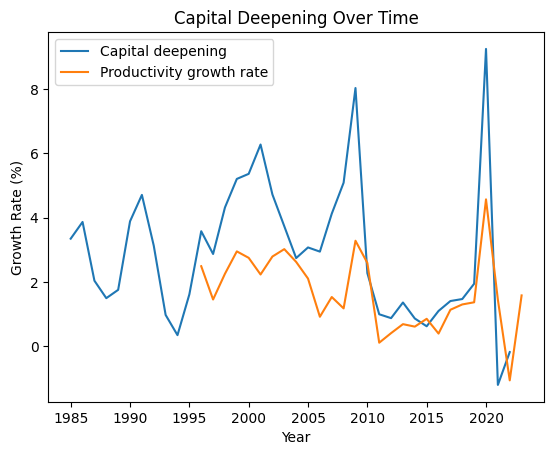

In [887]:
# plot capital deepening over time
pivot_growth['KSERHRS'].plot(label='Capital deepening')
pivot_growth['GDPHRS'].plot(label='Productivity growth rate')
plt.legend()
plt.title('Capital Deepening Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

What about technological progress? Has it declined over time?

Did the slowdown in productivity growth coincide with slower growth in technological progress?

Text(0, 0.5, 'Growth Rate (%)')

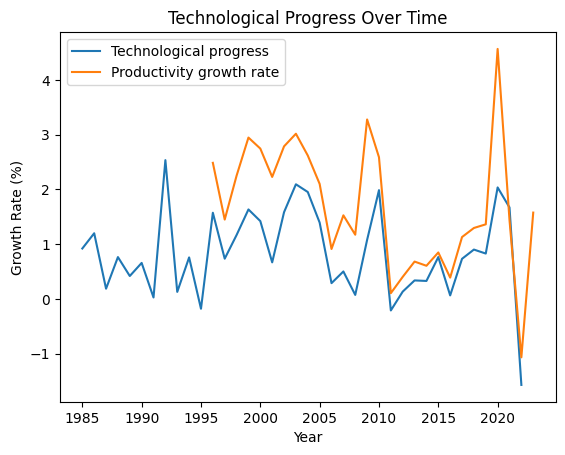

In [888]:
# plot technological progress over time against productivity growth rate
pivot_growth['MFPH'].plot(label='Technological progress')
pivot_growth['GDPHRS'].plot(label='Productivity growth rate')
plt.legend()
plt.title('Technological Progress Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

Weaker growth of both capital deepening and technological progress  seem to coincide with lower productivity growth.

To what extent is the slowdown due to weaker capital investment or weaker technological progress (MFPH)?



Text(0, 0.5, 'Growth Rate (%)')

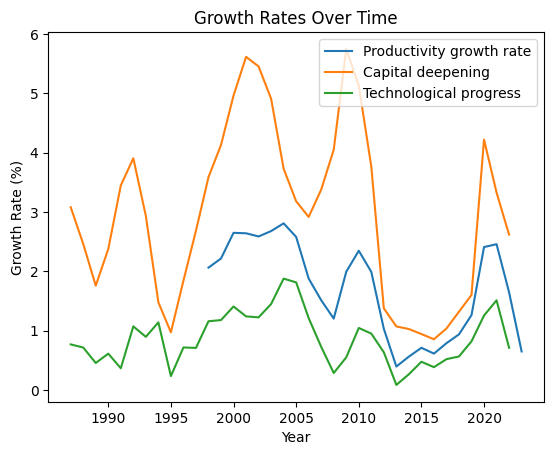

In [889]:
# plot all three growth rates with rolling means
pivot_growth['GDPHRS'].rolling(3).mean().plot(label='Productivity growth rate')
pivot_growth['KSERHRS'].rolling(3).mean().plot(label='Capital deepening')
pivot_growth['MFPH'].rolling(3).mean().plot(label='Technological progress')
plt.legend()
plt.title('Growth Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

Text(0, 0.5, 'Growth Rate (%)')

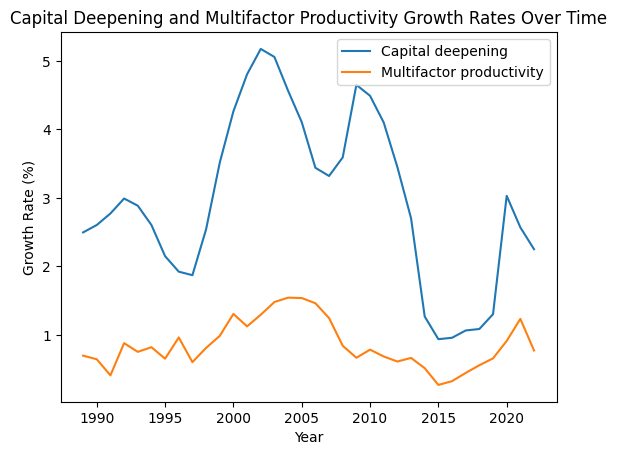

In [890]:
# plot growth rates of capital deepening and technological progress
pivot_growth['KSERHRS'].rolling(5).mean().plot(label='Capital deepening')
pivot_growth['MFPH'].rolling(5).mean().plot(label='Multifactor productivity')
plt.legend()
plt.title('Capital Deepening and Multifactor Productivity Growth Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

Growth Accounting Decomposition - My estimation

In [891]:
# capital share of income (standard estimate 0.33 for the US)
alpha = 0.33

pivot_growth['capital_contribution'] = alpha * pivot_growth['KSERHRS']

Text(0.5, 0, 'Year')

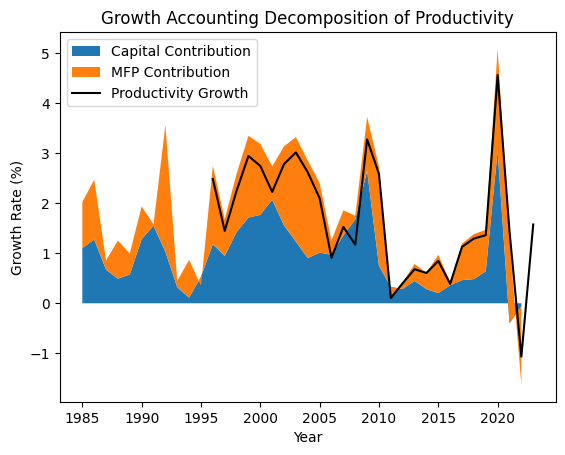

In [892]:
# stackplot of capital contribution & multifactor productivity
plt.stackplot(
    pivot_growth.index,
    pivot_growth['capital_contribution'],
    pivot_growth['MFPH'],
    labels=['Capital Contribution', 'MFP Contribution']
)

# line plot of productivity growth over the stacked plot
plt.plot(pivot_growth.index, pivot_growth['GDPHRS'], color='black', label='Productivity Growth')

# titles
plt.legend()
plt.title("Growth Accounting Decomposition of Productivity")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Year")


Growth Accounting Decomposition - OECD provided

* MFP_PCCONLP2 -	Contribution of MFP to labour productivity growth
* KSERHRS_PCCONLP - Contribution of capital deepening to labour productivity growth


<Axes: xlabel='OBS_VALUE', ylabel='Percent'>

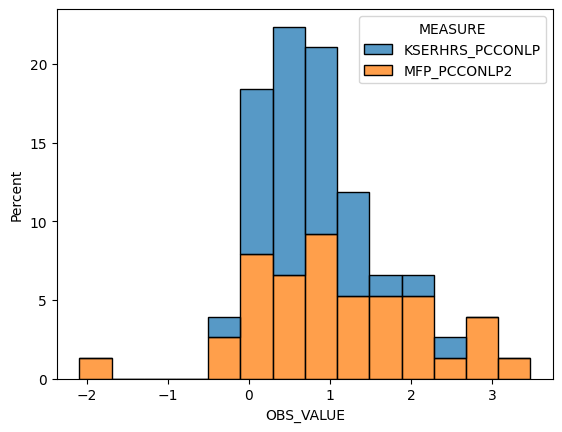

In [893]:
# another dataframe of just the two indicators
prod_contr = productivity[
    (productivity['MEASURE'] == 'KSERHRS_PCCONLP') |
    (productivity['MEASURE'] == 'MFP_PCCONLP2')
].copy()

# limit columns
prod_contr = prod_contr[['MEASURE', 'OBS_VALUE']]

# histplot
sns.histplot(
    data=prod_contr,
    x=prod_contr['OBS_VALUE'],
    hue='MEASURE',
    stat='percent',
    multiple='stack',
)

In [894]:
# for a stacked line plot

# pivot dataframe of just the two indicators: capital contribution & technological
selected2 = productivity[
    (productivity['MEASURE'] == 'MFP_PCCONLP2') |
    (productivity['MEASURE'] == 'KSERHRS_PCCONLP')
].copy()

pivot_decomp = selected2.pivot(index='TIME_PERIOD', columns='MEASURE', values='OBS_VALUE')
pivot_decomp.tail()

MEASURE,KSERHRS_PCCONLP,MFP_PCCONLP2
TIME_PERIOD,,
2018,0.388678,1.227016
2019,0.514111,1.127074
2020,2.423570,2.759790
2021,-0.308000,2.241166
2022,-0.046465,-2.089319


Text(0.5, 0, 'Year')

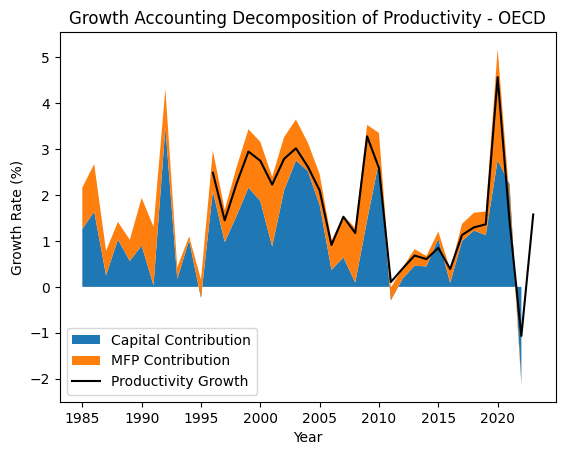

In [895]:
# stackplot of capital contribution & multifactor productivity
plt.stackplot(
    pivot_decomp.index,
    pivot_decomp['MFP_PCCONLP2'],
    pivot_decomp['KSERHRS_PCCONLP'],
    labels=['Capital Contribution', 'MFP Contribution']
)

# line plot of productivity growth over the stacked plot
plt.plot(pivot_growth.index, pivot_growth['GDPHRS'], color='black', label='Productivity Growth')

plt.legend()
plt.title("Growth Accounting Decomposition of Productivity - OECD")
plt.ylabel("Growth Rate (%)")
plt.xlabel("Year")

Pre vs. Post 2000 capital and technological contribution to labor productivity

* MFP_PCCONLP2 - Contribution of MFP to labour productivity growth
* KSERHRS_PCCONLP - Contribution of capital deepening to labour productivity growth
* NICTHRS_PCCONLP - Contribution of Non-ICT capital to labor productivity growwth
* ICTHRS_PCCONLP - Contribution of ICT capital to labor productivity growth

In [896]:
# create a column for whether that year (index) is pre or post 2000
productivity['Period'] = np.where(productivity.index<2000, 'Pre', 'Post')

In [897]:
# copy of dataframe for all contributions
prod_contr_4 = productivity[
    (productivity['MEASURE'] == 'KSERHRS_PCCONLP') |
    (productivity['MEASURE'] == 'MFP_PCCONLP2') |
    (productivity['MEASURE'] == 'NICTHRS_PCCONLP') |
    (productivity['MEASURE'] == 'ICTHRS_PCCONLP')
].copy()

# limit dataframe to only the columns needed
prod_contr_4 = prod_contr_4[['MEASURE', 'OBS_VALUE', 'Period']]

In [898]:
# check dataframe
prod_contr_4.head()

,MEASURE,OBS_VALUE,Period
TIME_PERIOD,,,
1985,ICTHRS_PCCONLP,0.527189,Pre
1985,KSERHRS_PCCONLP,0.901414,Pre
1985,NICTHRS_PCCONLP,0.374225,Pre
1985,MFP_PCCONLP2,1.260582,Pre
1986,MFP_PCCONLP2,1.639644,Pre


<Axes: xlabel='OBS_VALUE', ylabel='Period'>

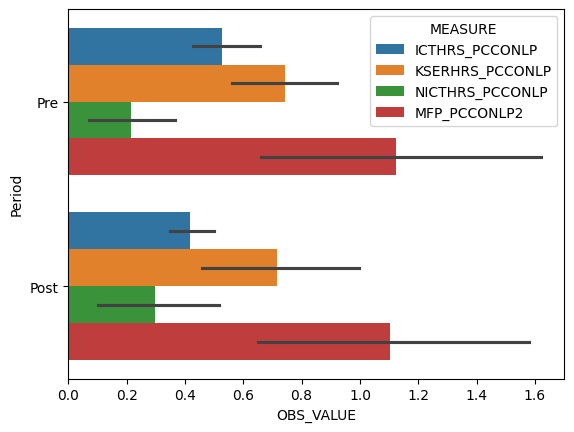

In [899]:
# bar plot of pre vs. post 2000 period of all contributions (mean estimator)
sns.barplot(data=prod_contr_4, y='Period', x='OBS_VALUE', hue='MEASURE', estimator='mean')

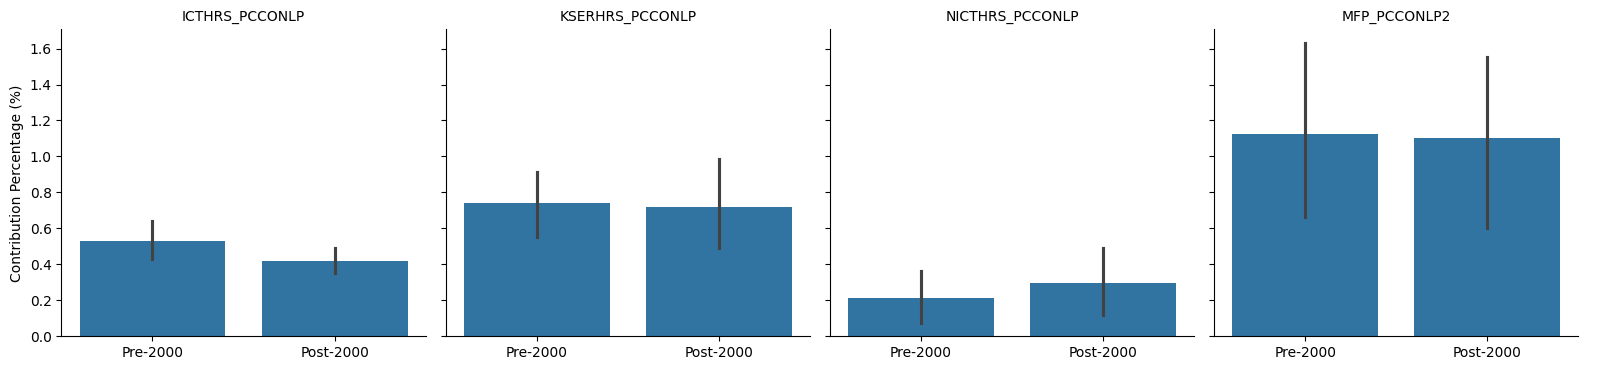

In [900]:
# catplot of all contributions pre vs. post 2000 (mean estimator)
g = sns.catplot(
    prod_contr_4, kind="bar",
    x="Period", y="OBS_VALUE", col="MEASURE", estimator='mean',
    height=4, aspect=1,
)
g.set_axis_labels("", "Contribution Percentage (%)")
g.set_xticklabels(["Pre-2000", "Post-2000"])
g.set_titles('{col_name}')

We see a decline in ICT capital contribution while Non-ICT capital contribution increases after 2000.

In [901]:
# limit contribution measures to only two (ICT & NICT)
prod_contr_2 = prod_contr_4[
            (prod_contr_4['MEASURE'] == 'ICTHRS_PCCONLP') |
            (prod_contr_4['MEASURE'] == 'NICTHRS_PCCONLP')
].copy()
prod_contr_2.head()

,MEASURE,OBS_VALUE,Period
TIME_PERIOD,,,
1985,ICTHRS_PCCONLP,0.527189,Pre
1985,NICTHRS_PCCONLP,0.374225,Pre
1986,ICTHRS_PCCONLP,0.488465,Pre
1986,NICTHRS_PCCONLP,0.548961,Pre
1987,NICTHRS_PCCONLP,0.124533,Pre


Text(0, 0.5, 'Contribution Percentage (%)')

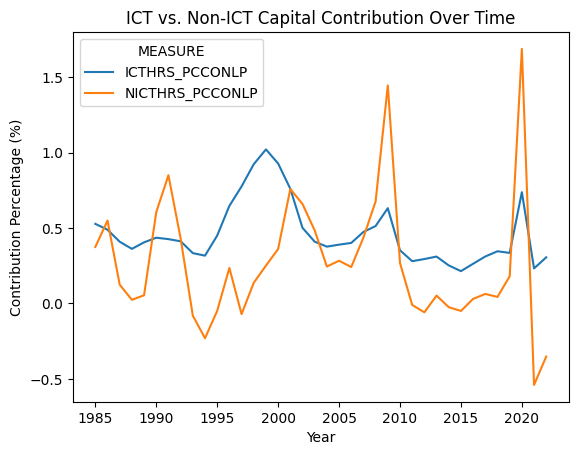

In [914]:
# line plot of ICT vs Non ICT contributions over time
g = sns.lineplot(data=prod_contr_2, x=prod_contr_2.index, y='OBS_VALUE', hue='MEASURE')
plt.title('ICT vs. Non-ICT Capital Contribution Over Time')
plt.xlabel('Year')
plt.ylabel('Contribution Percentage (%)')